In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy import NaN
import seaborn as sns

In [2]:
url = '/home/mansi/IOTDATA/IoT Network Intrusion Dataset.csv'
data=pd.read_csv(url)
data.shape

(625783, 86)

In [3]:
data.head(5)

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Cat,Sub_Cat
0,192.168.0.13-192.168.0.16-10000-10101-17,192.168.0.13,10000,192.168.0.16,10101,17,25/07/2019 03:25:53 AM,75,1,1,...,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Anomaly,Mirai,Mirai-Ackflooding
1,192.168.0.13-222.160.179.132-554-2179-6,222.160.179.132,2179,192.168.0.13,554,6,26/05/2019 10:11:06 PM,5310,1,2,...,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,Anomaly,DoS,DoS-Synflooding
2,192.168.0.13-192.168.0.16-9020-52727-6,192.168.0.16,52727,192.168.0.13,9020,6,11/07/2019 01:24:48 AM,141,0,3,...,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Anomaly,Scan,Scan Port OS
3,192.168.0.13-192.168.0.16-9020-52964-6,192.168.0.16,52964,192.168.0.13,9020,6,04/09/2019 03:58:17 AM,151,0,2,...,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Anomaly,Mirai,Mirai-Hostbruteforceg
4,192.168.0.1-239.255.255.250-36763-1900-17,192.168.0.1,36763,239.255.255.250,1900,17,10/09/2019 01:41:18 AM,153,2,1,...,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Anomaly,Mirai,Mirai-Hostbruteforceg


In [4]:
# remove attribute 'difficulty_level'
data.drop(['Label','Sub_Cat'],axis=1,inplace=True)
data.shape

(625783, 84)

In [5]:
data.describe()

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Fwd_Act_Data_Pkts,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
count,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.00000,625783.000000,625783.000000,625783.000000,625783.000000,...,625783.000000,625783.0,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000,625783.000000
mean,35026.156190,16387.027479,9.971436,635.422865,1.675566,1.46853,570.738980,929.280973,392.489726,348.126571,...,1.509913,0.0,3.764405,0.353385,4.248735,3.462159,502.503832,52.403995,561.540512,467.264459
std,24721.047752,17550.363037,5.379857,3496.740723,4.309970,1.21949,1161.873195,1731.760875,619.575865,588.161845,...,4.332737,0.0,68.064508,20.723370,88.934148,64.111043,2112.957360,1153.184897,2866.497606,1931.909971
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9020.000000,8899.000000,6.000000,76.000000,0.000000,1.00000,0.000000,18.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,73.000000,0.000000,74.000000,71.000000
50%,51991.000000,9020.000000,6.000000,132.000000,1.000000,1.00000,32.000000,104.000000,30.000000,30.000000,...,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,93.500000,0.000000,114.000000,78.000000
75%,56361.000000,10101.000000,17.000000,221.000000,2.000000,2.00000,1388.000000,1441.000000,1388.000000,386.000000,...,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,141.000000,1.527525,154.000000,130.000000
max,65500.000000,65371.000000,17.000000,99984.000000,186.000000,560.00000,109846.000000,773284.000000,1464.000000,1464.000000,...,186.000000,0.0,9044.625000,8598.658250,26785.000000,6659.000000,99973.000000,67071.906623,99973.000000,99973.000000


In [6]:
# number of attack labels 
data['Cat'].value_counts()

Mirai                415677
Scan                  75265
DoS                   59391
Normal                40073
MITM ARP Spoofing     35377
Name: Cat, dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625783 entries, 0 to 625782
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow_ID            625783 non-null  object 
 1   Src_IP             625783 non-null  object 
 2   Src_Port           625783 non-null  int64  
 3   Dst_IP             625783 non-null  object 
 4   Dst_Port           625783 non-null  int64  
 5   Protocol           625783 non-null  int64  
 6   Timestamp          625783 non-null  object 
 7   Flow_Duration      625783 non-null  int64  
 8   Tot_Fwd_Pkts       625783 non-null  int64  
 9   Tot_Bwd_Pkts       625783 non-null  int64  
 10  TotLen_Fwd_Pkts    625783 non-null  float64
 11  TotLen_Bwd_Pkts    625783 non-null  float64
 12  Fwd_Pkt_Len_Max    625783 non-null  float64
 13  Fwd_Pkt_Len_Min    625783 non-null  float64
 14  Fwd_Pkt_Len_Mean   625783 non-null  float64
 15  Fwd_Pkt_Len_Std    625783 non-null  float64
 16  Bw

In [8]:
dataset = data['Cat']


/home/mansi/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Mirai'),
  Text(1, 0, 'DoS'),
  Text(2, 0, 'Scan'),
  Text(3, 0, 'Normal'),
  Text(4, 0, 'MITM ARP Spoofing')])

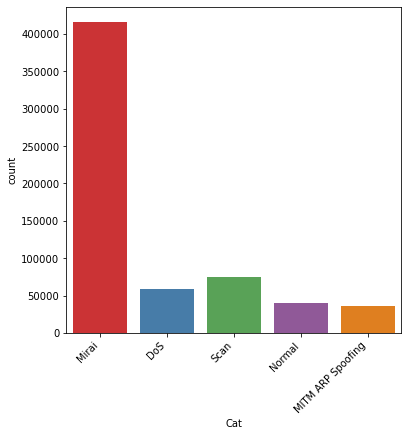

In [9]:
plt.figure(figsize=(6,6))
chart = sns.countplot(dataset, palette="Set1")
plt.xticks(rotation=45, horizontalalignment="right")

In [10]:
# Checking if there are any NULL values in the dataset.

data.isnull().values.any()

False

In [11]:
# Checking which column/s contain NULL values.

[col for col in data if data[col].isnull().values.any()]

[]

In [12]:
from sklearn.preprocessing import LabelEncoder

ord_enc = LabelEncoder()
data["Flow_ID"] = ord_enc.fit_transform(data[["Flow_ID"]])
data["Src_IP"] = ord_enc.fit_transform(data[["Src_IP"]])
data["Dst_IP"] = ord_enc.fit_transform(data[["Dst_IP"]])
data["Timestamp"] = ord_enc.fit_transform(data[["Timestamp"]])

/home/mansi/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:115: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [13]:
# Drop the repeated rows
df=data.drop_duplicates()

In [14]:
labl = df['Cat']
dataset = df.loc[:, df.columns != 'Cat'].astype('float64')

In [15]:
# Checking if all values are finite.

np.all(np.isfinite(dataset))

False

In [16]:
# Checking what column/s contain non-finite values.

nonfinite = [col for col in dataset if not np.all(np.isfinite(dataset[col]))]

nonfinite

['Flow_Byts/s', 'Flow_Pkts/s']

In [17]:
# Checking how many non-finite values each column contains.

finite = np.isfinite(dataset['Flow_Byts/s']).sum()

dataset.shape[0] - finite

323

In [18]:
# Checking how many non-finite values each column contains.

finite = np.isfinite(dataset['Flow_Pkts/s']).sum()

dataset.shape[0] - finite

323

In [19]:
# Same as before, since there is a small number of non-finite values we can safely remove them from the dataset
# without spoiling the dataset.

# Replacing infinite values with NaN values.
dataset = dataset.replace([np.inf, -np.inf], np.nan)

In [20]:
# We can see that now we have Nan values again.

np.any(np.isnan(dataset))

True

In [21]:
# Bringing the Labels back into the dataset before deliting Nan rows.

dataset = dataset.merge(labl, how='outer', left_index=True, right_index=True)

In [22]:
# Removing new NaN values.

dataset.dropna(inplace=True)

In [23]:
dataset.shape

(411382, 84)

In [24]:
dataset.head()

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Cat
0,12446.0,25883.0,10000.0,203.0,10101.0,17.0,3496.0,75.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Mirai
1,22760.0,34617.0,2179.0,200.0,554.0,6.0,3664.0,5310.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,DoS
2,12691.0,25886.0,52727.0,200.0,9020.0,6.0,2082.0,141.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Scan
3,12704.0,25886.0,52964.0,200.0,9020.0,6.0,791.0,151.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Mirai
4,611.0,25881.0,36763.0,317.0,1900.0,17.0,1040.0,153.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Mirai


In [25]:
dataset['Cat'].value_counts()

Mirai                230788
DoS                   59390
Scan                  56744
Normal                38598
MITM ARP Spoofing     25862
Name: Cat, dtype: int64

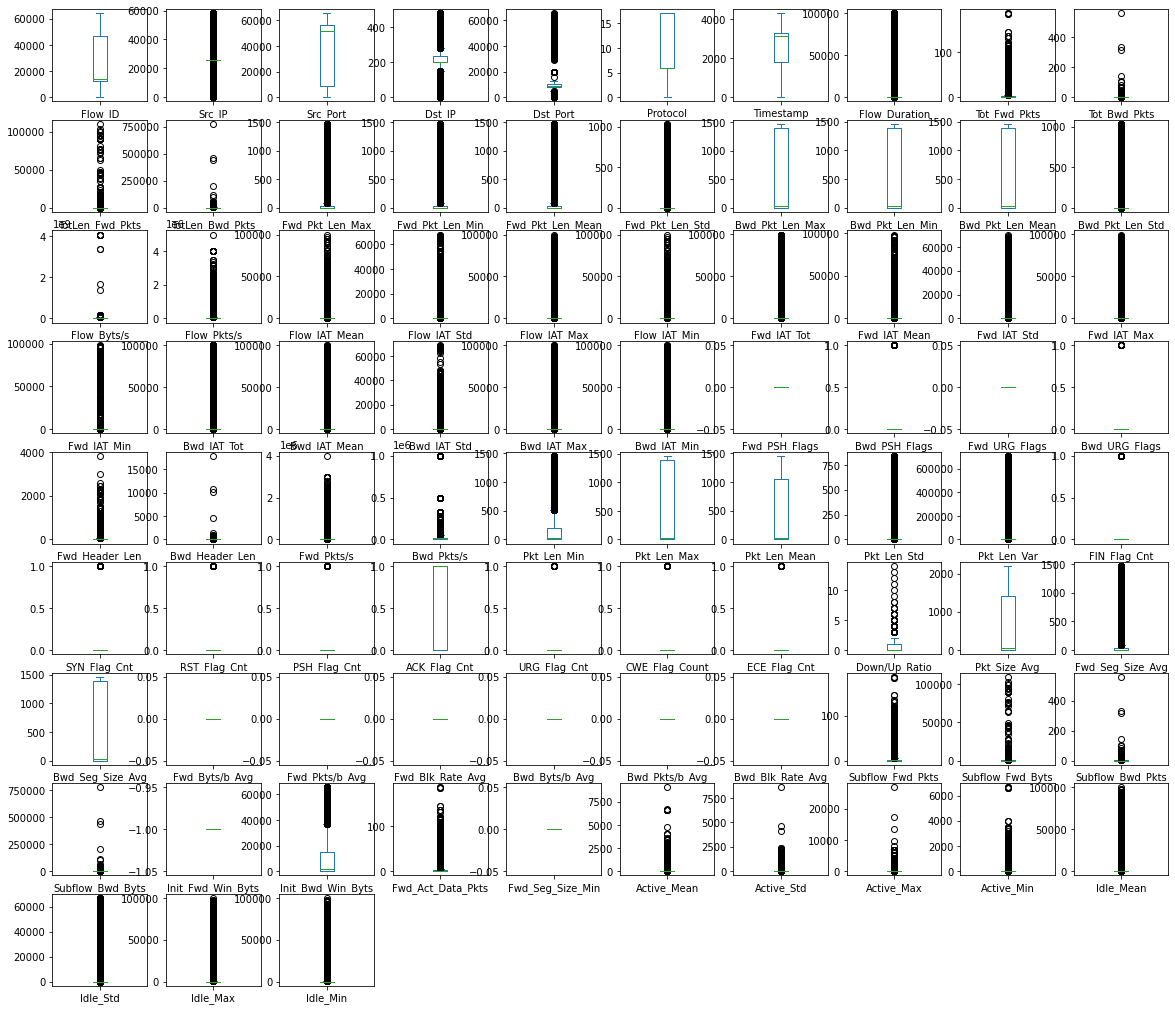

In [26]:
# box and whisker plot for outliers

dataset.plot(kind="box",subplots=True, layout=(10,10),sharex=False,sharey=False,figsize=(20,20))
plt.show()

In [27]:
# using standard scaler for normalizing
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
def normalization(df,col):
  for i in col:
    arr = df[i]
    arr = np.array(arr)
    df[i] = std_scaler.fit_transform(arr.reshape(len(arr),1))
  return df

In [28]:
# creating a dataframe with multi-class labels
from sklearn import preprocessing
numeric_col = dataset.select_dtypes(include='number').columns
dataset = normalization(dataset.copy(),numeric_col)





In [29]:
multi_data = dataset.copy()
multi_label = pd.DataFrame(multi_data.Cat)

In [30]:
# label encoding
le2_test = preprocessing.LabelEncoder()
enc_label = multi_label.apply(le2_test.fit_transform)
multi_data['intrusion'] = enc_label

In [31]:
# one-hot-encoding attack label
multi_data = pd.get_dummies(multi_data,columns=['Cat'],prefix="",prefix_sep="") 
multi_data['Cat'] = multi_label
multi_data

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Idle_Std,Idle_Max,Idle_Min,intrusion,DoS,MITM ARP Spoofing,Mirai,Normal,Scan,Cat
0,-0.709812,0.073387,-1.097955,-0.159136,-0.297670,1.385704,0.861750,-0.189646,-0.196043,-0.354896,...,-0.053756,-0.204341,-0.245423,2,0,0,1,0,0,Mirai
1,-0.232045,1.061937,-1.418388,-0.226262,-0.851415,-0.694809,1.022992,1.030456,-0.196043,0.354889,...,1.536877,0.985235,0.170110,0,1,0,0,0,0,DoS
2,-0.698463,0.073727,0.652609,-0.226262,-0.360371,-0.694809,-0.495373,-0.174264,-0.386957,1.064674,...,-0.053258,-0.205480,-0.247541,4,0,0,0,0,1,Scan
3,-0.697861,0.073727,0.662319,-0.226262,-0.360371,-0.694809,-1.734444,-0.171933,-0.386957,0.354889,...,-0.053756,-0.182707,-0.213231,2,0,0,1,0,0,Mirai
4,-1.258035,0.073161,-0.001451,2.391645,-0.773345,1.385704,-1.495460,-0.171467,-0.005130,-0.354896,...,-0.053258,-0.203772,-0.245000,2,0,0,1,0,0,Mirai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625773,1.605972,0.074066,0.957350,0.512122,-0.367389,1.385704,0.620846,-0.200367,0.567610,-0.354896,...,-0.051402,-0.222559,-0.275921,2,0,0,1,0,0,Mirai
625776,1.440694,-0.475442,-1.149619,-0.114385,0.253523,-0.694809,-1.980146,0.047382,-0.386957,0.354889,...,-0.053756,0.085154,0.185359,0,1,0,0,0,0,DoS
625778,1.589389,0.074066,0.791295,0.512122,-0.417038,1.385704,0.810881,-0.142567,-0.196043,-0.354896,...,-0.053756,-0.146841,-0.159860,2,0,0,1,0,0,Mirai
625779,-0.417334,0.609880,-1.320427,-0.226262,-0.851415,-0.694809,0.997078,0.179298,-0.386957,0.354889,...,-0.053756,0.246269,0.425106,0,1,0,0,0,0,DoS


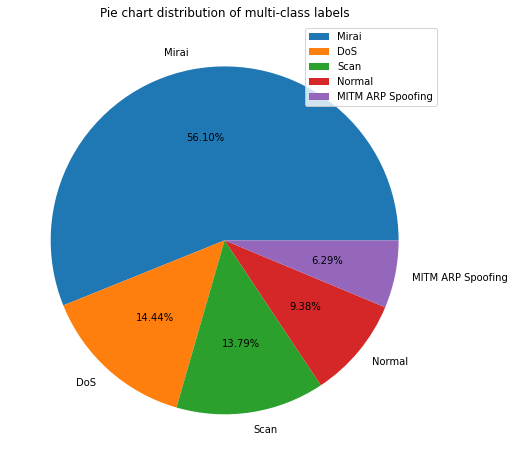

In [32]:
# pie chart distribution of multi-class labels
plt.figure(figsize=(8,8))
plt.pie(multi_data.Cat.value_counts(),labels=multi_data.Cat.unique(),autopct='%0.2f%%')
plt.title('Pie chart distribution of multi-class labels')
plt.legend()
plt.show()

In [33]:
# creating a dataframe with only numeric attributes of multi-class dataset and encoded label attribute


numeric_multi = multi_data[numeric_col]
numeric_multi['intrusion'] = multi_data['intrusion']

/tmp/ipykernel_620520/856718132.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_multi['intrusion'] = multi_data['intrusion']


In [34]:
# finding the attributes which have more than 0.5 correlation with encoded attack label attribute 
corr = numeric_multi.corr()
corr_y = abs(corr['intrusion'])
highest_corr = corr_y[corr_y >0.2]
highest_corr.sort_values(ascending=True)

Pkt_Len_Min         0.206749
Pkt_Len_Var         0.232915
Pkt_Len_Std         0.233685
Bwd_Pkt_Len_Min     0.262157
Src_Port            0.299144
Flow_Duration       0.310543
Pkt_Size_Avg        0.311489
Bwd_Pkt_Len_Mean    0.313733
Bwd_Seg_Size_Avg    0.313733
Pkt_Len_Mean        0.316520
Bwd_IAT_Tot         0.328604
Bwd_Pkt_Len_Max     0.333577
Pkt_Len_Max         0.335450
Dst_Port            0.341456
Idle_Max            0.346567
Flow_IAT_Max        0.349534
Bwd_IAT_Max         0.359086
Bwd_IAT_Min         0.399313
Bwd_IAT_Mean        0.404231
Idle_Mean           0.419217
Idle_Min            0.425997
Flow_IAT_Mean       0.445886
Flow_IAT_Min        0.447646
ACK_Flag_Cnt        0.528705
SYN_Flag_Cnt        0.718676
intrusion           1.000000
Name: intrusion, dtype: float64

In [35]:
# selecting attributes found by using pearson correlation coefficient
numeric_multi = multi_data[['Pkt_Len_Min','Pkt_Len_Var','Pkt_Len_Std','Bwd_Pkt_Len_Min','Src_Port','Flow_Duration',
                            'Pkt_Size_Avg','Bwd_Pkt_Len_Mean','Bwd_Seg_Size_Avg','Pkt_Len_Mean','Bwd_IAT_Tot',
                            'Bwd_Pkt_Len_Max','Pkt_Len_Max','Dst_Port','Idle_Max','Flow_IAT_Max','Bwd_IAT_Max',
                            'Bwd_IAT_Min','Bwd_IAT_Mean','Idle_Mean','Idle_Min','Flow_IAT_Mean','Flow_IAT_Min',
                            'ACK_Flag_Cnt','SYN_Flag_Cnt']]

# then joining encoded, one-hot-encoded, and original attack label attribute
multi_data = numeric_multi.join(multi_data[['intrusion','Mirai','DoS','Scan','Normal','MITM ARP Spoofing','Cat']])

In [36]:
multi_data

,Pkt_Len_Min,Pkt_Len_Var,Pkt_Len_Std,Bwd_Pkt_Len_Min,Src_Port,Flow_Duration,Pkt_Size_Avg,Bwd_Pkt_Len_Mean,Bwd_Seg_Size_Avg,Pkt_Len_Mean,...,Flow_IAT_Min,ACK_Flag_Cnt,SYN_Flag_Cnt,intrusion,Mirai,DoS,Scan,Normal,MITM ARP Spoofing,Cat
0,1.137632,-0.013904,0.649157,1.666777,-1.097955,-0.189646,1.455627,1.580407,1.580407,1.376925,...,-0.258419,-1.018921,-0.405749,2,1,0,0,0,0,Mirai
1,-0.585187,-0.385863,-0.413158,-0.654467,-1.418388,1.030456,-0.751558,-0.741622,-0.741622,-0.756864,...,0.208920,-1.018921,2.464575,0,0,1,0,0,0,DoS
2,-0.532556,2.177439,2.375569,-0.605769,0.652609,-0.174264,0.854712,0.777169,0.777169,0.990099,...,-0.260800,0.981431,-0.405749,4,0,0,1,0,0,Scan
3,1.849918,-0.385863,-0.413158,1.598600,0.662319,-0.171933,1.640613,1.512208,1.512208,1.555759,...,-0.222213,0.981431,-0.405749,2,1,0,0,0,0,Mirai
4,0.151660,-0.384583,-0.350826,0.027297,-0.001451,-0.171467,-0.090513,-0.059627,-0.059627,-0.037918,...,-0.257942,-1.018921,-0.405749,2,1,0,0,0,0,Mirai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625773,-0.529047,-0.385863,-0.413158,-0.602523,0.957350,-0.200367,-0.708663,-0.689660,-0.689660,-0.703547,...,-0.292719,-1.018921,-0.405749,2,1,0,0,0,0,Mirai
625776,-0.585187,-0.385863,-0.413158,-0.654467,-1.149619,0.047382,-0.751558,-0.741622,-0.741622,-0.756864,...,0.226070,-1.018921,2.464575,0,0,1,0,0,0,DoS
625778,-0.553608,-0.385863,-0.413158,-0.625248,0.791295,-0.142567,-0.720536,-0.712393,-0.712393,-0.726873,...,-0.162188,-1.018921,-0.405749,2,1,0,0,0,0,Mirai
625779,-0.585187,-0.385863,-0.413158,-0.654467,-1.320427,0.179298,-0.751558,-0.741622,-0.741622,-0.756864,...,0.495707,-1.018921,2.464575,0,0,1,0,0,0,DoS


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,precision_recall_fscore_support
from sklearn.metrics import accuracy_score,roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import ExtraTreesClassifier
import time
import warnings

In [42]:
# classifier for multiclass classification dataset

warnings.filterwarnings("ignore")

X = multi_data.iloc[:,0:25].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = multi_data['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)
# Spot Check Algorithms
# Spot Check Algorithms
models = []
models.append(('LR',  LogisticRegression(solver='lbfgs', multi_class='ovr')))
#solver='lbfgs',multi_class='multinomial',tol=0.0000000001
models.append(('LDA', LinearDiscriminantAnalysis(n_components=3)))
models.append(('KNN', KNeighborsClassifier(n_neighbors=3)))
models.append(('CART',DecisionTreeClassifier()))
models.append(('SVM', SVC(max_iter=1000,gamma=0.001)))

print ('Model\tAcc\tFAR\tsen\tspe\tExecution_time')

# evaluate each model in turn
results = []
names = []

for name, model in models:
    start_time = time.time()
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy').mean()
    
    
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    cm = confusion_matrix(Y_validation, predict)
    # Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
    cm_df = pd.DataFrame(cm)
    
    total1=sum(sum(cm))
    false_alaram_rate = cm[1,0]/(cm[1,0]+cm[0,0])
    sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
    specificity = cm[0,0]/(cm[1,0]+cm[0,0])
    f1score = precision_recall_fscore_support(Y_validation, predict,average='weighted')
    
    delta = time.time() - start_time
    results.append(cv_results)
    names.append(name)
    print('{}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.2f} sec'.format(name, cv_results, false_alaram_rate, sensitivity, specificity, delta))
    print(f1score)
    print(cm_df)

Model	Acc	FAR	sen	spe	Execution_time
LR	0.749	0.000	1.000	1.000	84.70 sec
(0.6952443070727485, 0.7565297713820387, 0.7110549914306464, None)
       0    1      2     3     4
0  11838    0     36     2     0
1      0   28   4218    22   814
2      0  456  42659  1467  1544
3      2   73   2050  5613    59
4      0   15   8167  1107  2107
LDA	0.738	0.000	0.988	1.000	9.39 sec
(0.7544902117014505, 0.737885435783998, 0.7437818880245558, None)
       0     1      2     3     4
0  11721    18    106    25     6
1      2  1504   1500    66  2010
2     52  2775  35737  2073  5489
3      1    47   1819  4992   938
4      6   145   3276  1212  6757
KNN	0.982	0.000	1.000	1.000	1209.52 sec
(0.9818387676542987, 0.9817445944796237, 0.981781049309893, None)
       0     1      2     3      4
0  11862     0      7     5      2
1      1  4720    282     7     72
2      5   319  45533    38    231
3      2    43    106  7626     20
4      3   101    246    12  11034
CART	0.994	0.000	1.000	1.000	25.22 sec

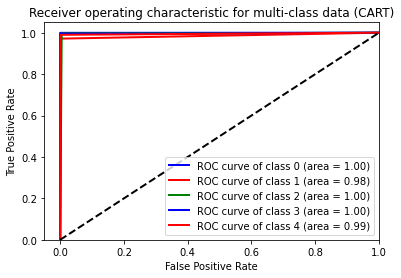

In [43]:
#Creating plot to show the ROC for all models


from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

X = multi_data.iloc[:,0:25].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = multi_data['intrusion'] # target attribute

# Binarize the output
y = label_binarize(y, classes=[0, 1, 2,3,4])
n_classes = y.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=0)

#classifier = OneVsRestClassifier(svm.SVC(kernel='linear', probability=True,random_state=0))

classifier = OneVsRestClassifier(DecisionTreeClassifier())

y_score = classifier.fit(X_train, y_train)
ypred = y_score.predict(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
lw=2
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], ypred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for multi-class data (CART)')
plt.legend(loc="lower right")
plt.show()